# Discrete Random Vector

Let $X_1, X_2, \ldots, X_d$ be $d$ discrete random variables.

**Discrete random vector** — a column vector of random variables:

$$\mathbf{X} = [X_1 \; X_2 \; \cdots \; X_d]^\top$$

**Mean vector** — expectation applied component-wise:

$$\boldsymbol{\mu} = E[\mathbf{X}] = \begin{bmatrix} E[X_1] \\ E[X_2] \\ \vdots \\ E[X_d] \end{bmatrix}$$

**Variance vector** — per-component variance:

$$\boldsymbol{\sigma}^2 = \begin{bmatrix} E[(X_1 - \mu_1)^2] \\ E[(X_2 - \mu_2)^2] \\ \vdots \\ E[(X_d - \mu_d)^2] \end{bmatrix}$$

**Covariance matrix** — pairwise covariances between all components:

$$\Sigma = E[(\mathbf{X} - \boldsymbol{\mu})(\mathbf{X} - \boldsymbol{\mu})^\top] = \begin{bmatrix} \sigma_1^2 & \sigma_{12} & \cdots & \sigma_{1d} \\ \sigma_{21} & \sigma_2^2 & \cdots & \sigma_{2d} \\ \vdots & & \ddots & \vdots \\ \sigma_{d1} & \sigma_{d2} & \cdots & \sigma_d^2 \end{bmatrix}$$

where $\Sigma_{ij} = \sigma_{ij} = E[(X_i - \mu_i)(X_j - \mu_j)]$ and $\Sigma$ is **symmetric** ($\sigma_{ij} = \sigma_{ji}$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Example: 3-Dimensional Discrete Random Vector

Let $\mathbf{X} = [X_1, X_2, X_3]^\top$ where each component takes values from a discrete joint distribution.

We use a concrete example — **dice roll outcomes**:
- $X_1$: face of die 1 (uniform on $\{1,\ldots,6\}$)
- $X_2 = X_1 + \epsilon$ (positively correlated with $X_1$)
- $X_3$: independent die roll

We compute $\boldsymbol{\mu}$, $\boldsymbol{\sigma}^2$, and $\Sigma$ from samples.

In [2]:
rng = np.random.default_rng(42)
N   = 10_000

X1 = rng.integers(1, 7, size=N)                        # die 1: uniform {1..6}
X2 = np.clip(X1 + rng.integers(-1, 2, size=N), 1, 6)   # correlated with X1
X3 = rng.integers(1, 7, size=N)                        # independent die

# Stack into random vector  X shape: (N, 3)
X = np.stack([X1, X2, X3], axis=1).astype(float)

# ── Mean vector μ ──────────────────────────────────────────
mu = X.mean(axis=0)

# ── Variance vector σ² ─────────────────────────────────────
var = X.var(axis=0)

# ── Covariance matrix Σ ─────────────────────────────────────
Sigma = np.cov(X.T)   # shape (3, 3)

print("Mean vector  μ = E[X]:")
for i, m in enumerate(mu, 1):
    print(f"  μ_{i} = E[X_{i}] = {m:.4f}")

print()
print("Variance vector  σ²:")
for i, v in enumerate(var, 1):
    print(f"  σ²_{i} = E[(X_{i}-μ_{i})²] = {v:.4f}")

print()
print("Covariance matrix  Σ  (3×3):")
labels = ['X1', 'X2', 'X3']
header = "        " + "  ".join(f"{l:>8}" for l in labels)
print(header)
for i, row in enumerate(Sigma):
    print(f"  {labels[i]:>4}  " + "  ".join(f"{v:8.4f}" for v in row))

print()
print(f"Symmetric (Σ = Σᵀ): {np.allclose(Sigma, Sigma.T)}")

Mean vector  μ = E[X]:
  μ_1 = E[X_1] = 3.4752
  μ_2 = E[X_2] = 3.4699
  μ_3 = E[X_3] = 3.5212

Variance vector  σ²:
  σ²_1 = E[(X_1-μ_1)²] = 2.9052
  σ²_2 = E[(X_2-μ_2)²] = 2.9221
  σ²_3 = E[(X_3-μ_3)²] = 2.9122

Covariance matrix  Σ  (3×3):
              X1        X2        X3
    X1    2.9055    2.6379    0.0500
    X2    2.6379    2.9224    0.0453
    X3    0.0500    0.0453    2.9124

Symmetric (Σ = Σᵀ): True


## Visualising the Mean Vector and Variance Vector

Bar charts of $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}^2$ alongside the PMF of each component.

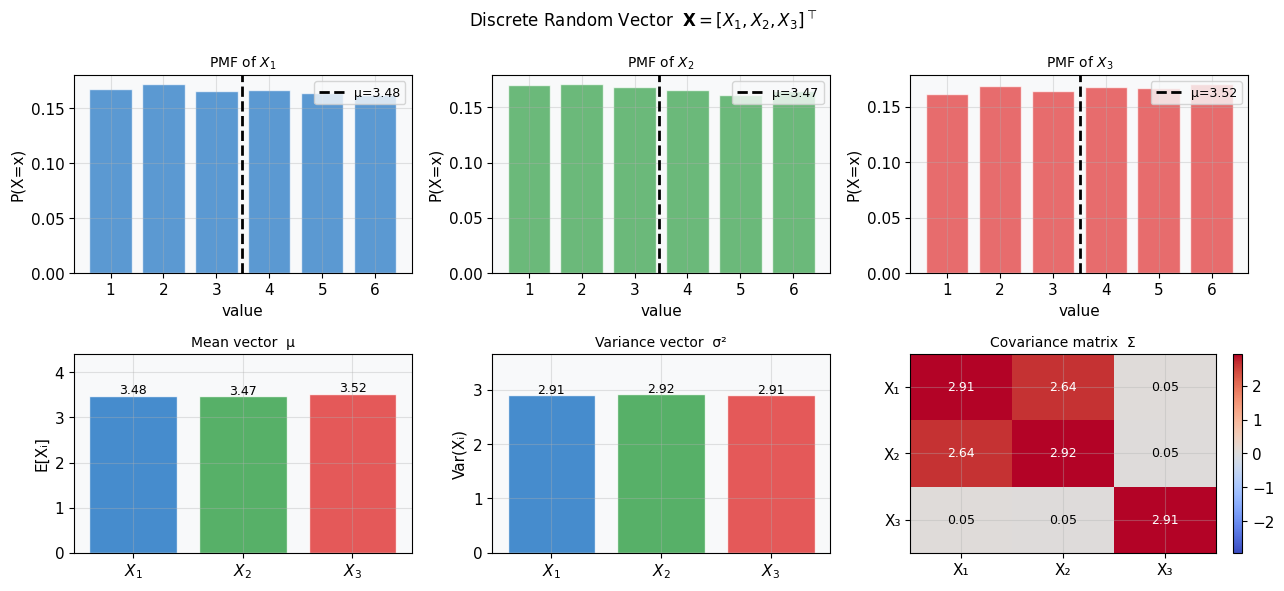

In [3]:
colors = ['#1971c2', '#2f9e44', '#e03131']
comp_labels = ['$X_1$', '$X_2$', '$X_3$']
vals = np.arange(1, 7)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

# Row 0: PMFs with mean marked
for j, (col, lbl, data) in enumerate(zip(colors, comp_labels, [X1, X2, X3])):
    ax = axes[0, j]
    counts = np.array([(data == v).sum() for v in vals]) / N
    ax.bar(vals, counts, color=col, alpha=0.7, edgecolor='white')
    ax.axvline(mu[j], color='black', lw=2, ls='--', label=f'μ={mu[j]:.2f}')
    ax.set_title(f'PMF of {lbl}', fontsize=10)
    ax.set_xlabel('value')
    ax.set_ylabel('P(X=x)')
    ax.legend(fontsize=9)

# Row 1: Mean vector and Variance vector (bar charts)
ax_mu = axes[1, 0]
ax_mu.bar(comp_labels, mu, color=colors, alpha=0.8, edgecolor='white')
for i, v in enumerate(mu):
    ax_mu.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)
ax_mu.set_title('Mean vector  μ', fontsize=10)
ax_mu.set_ylabel('E[Xᵢ]')
ax_mu.set_ylim(0, max(mu)*1.25)

ax_var = axes[1, 1]
ax_var.bar(comp_labels, var, color=colors, alpha=0.8, edgecolor='white')
for i, v in enumerate(var):
    ax_var.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
ax_var.set_title('Variance vector  σ²', fontsize=10)
ax_var.set_ylabel('Var(Xᵢ)')
ax_var.set_ylim(0, max(var)*1.25)

# Heatmap of covariance matrix
ax_cov = axes[1, 2]
im = ax_cov.imshow(Sigma, cmap='coolwarm', aspect='auto',
                   vmin=-np.abs(Sigma).max(), vmax=np.abs(Sigma).max())
ax_cov.set_xticks([0, 1, 2]); ax_cov.set_xticklabels(['X₁', 'X₂', 'X₃'])
ax_cov.set_yticks([0, 1, 2]); ax_cov.set_yticklabels(['X₁', 'X₂', 'X₃'])
ax_cov.set_title('Covariance matrix  Σ', fontsize=10)
for i in range(3):
    for j in range(3):
        ax_cov.text(j, i, f'{Sigma[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if abs(Sigma[i, j]) > Sigma.max()*0.5 else 'black')
plt.colorbar(im, ax=ax_cov, fraction=0.046)

plt.suptitle('Discrete Random Vector  $\\mathbf{X} = [X_1, X_2, X_3]^\\top$', fontsize=12)
plt.tight_layout()
plt.show()

## Covariance Matrix — Structure

$$\Sigma_{ij} = E[(X_i - \mu_i)(X_j - \mu_j)]$$

- **Diagonal** ($i = j$): variance of each component $\sigma_i^2$
- **Off-diagonal** ($i \neq j$): covariance between components $\sigma_{ij}$
- **Symmetric**: $\sigma_{ij} = \sigma_{ji}$

Compact outer-product form:

$$\Sigma = E\!\left[(\mathbf{X} - \boldsymbol{\mu})(\mathbf{X} - \boldsymbol{\mu})^\top\right]$$

In [4]:
# Verify outer-product formula: Σ = E[(X - μ)(X - μ)ᵀ]
X_centred = X - mu                        # shape (N, 3)
Sigma_outer = (X_centred.T @ X_centred) / (N - 1)   # unbiased estimate

print("Σ via np.cov:")
print(np.round(Sigma, 4))
print()
print("Σ via outer-product formula  E[(X-μ)(X-μ)ᵀ]:")
print(np.round(Sigma_outer, 4))
print()
print(f"Both agree: {np.allclose(Sigma, Sigma_outer, atol=1e-10)}")
print(f"Symmetric:  {np.allclose(Sigma, Sigma.T)}")
print()
# Show individual σ_ij entries
print("Individual entries  σᵢⱼ = E[(Xᵢ-μᵢ)(Xⱼ-μⱼ)]:")
for i in range(3):
    for j in range(3):
        tag = "← variance" if i == j else ("← cov" if j > i else "")
        print(f"  σ_{i+1}{j+1} = {Sigma[i,j]:7.4f}  {tag}")

Σ via np.cov:
[[2.9055 2.6379 0.05  ]
 [2.6379 2.9224 0.0453]
 [0.05   0.0453 2.9124]]

Σ via outer-product formula  E[(X-μ)(X-μ)ᵀ]:
[[2.9055 2.6379 0.05  ]
 [2.6379 2.9224 0.0453]
 [0.05   0.0453 2.9124]]

Both agree: True
Symmetric:  True

Individual entries  σᵢⱼ = E[(Xᵢ-μᵢ)(Xⱼ-μⱼ)]:
  σ_11 =  2.9055  ← variance
  σ_12 =  2.6379  ← cov
  σ_13 =  0.0500  ← cov
  σ_21 =  2.6379  
  σ_22 =  2.9224  ← variance
  σ_23 =  0.0453  ← cov
  σ_31 =  0.0500  
  σ_32 =  0.0453  
  σ_33 =  2.9124  ← variance


## Summary

| Concept | Definition | Shape |
|---|---|---|
| **Random vector** | $\mathbf{X} = [X_1, \ldots, X_d]^\top$ | $(d,)$ |
| **Mean vector** | $\boldsymbol{\mu} = E[\mathbf{X}]$, component $\mu_i = E[X_i]$ | $(d,)$ |
| **Variance vector** | $\boldsymbol{\sigma}^2$, component $\sigma_i^2 = E[(X_i-\mu_i)^2]$ | $(d,)$ |
| **Covariance matrix** | $\Sigma = E[(\mathbf{X}-\boldsymbol{\mu})(\mathbf{X}-\boldsymbol{\mu})^\top]$ | $(d \times d)$ |
| Diagonal of $\Sigma$ | Variances $\sigma_i^2$ | — |
| Off-diagonal of $\Sigma$ | Covariances $\sigma_{ij}$ | — |
| $\Sigma$ is symmetric | $\sigma_{ij} = \sigma_{ji}$ | — |